# EDA - creditcard.csv (Bank Credit Card Transactions)

## Objective
Comprehensive exploratory data analysis and preprocessing of credit card fraud data, including:
- Data cleaning (missing values, duplicates, data types)
- Univariate and bivariate analysis
- Class imbalance quantification
- Feature distribution analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading and Initial Exploration

In [2]:
# Load dataset
creditcard_data = pd.read_csv('../data/raw/creditcard.csv')

print("Credit Card Data shape:", creditcard_data.shape)
print("\nFirst few rows:")
print(creditcard_data.head())
print("\nData Info:")
print(creditcard_data.info())

Credit Card Data shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0

In [3]:
# Column names and description
print("Columns in dataset:")
print(creditcard_data.columns.tolist())

print("\nData types:")
print(creditcard_data.dtypes)

Columns in dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


## 2. Data Cleaning

In [4]:
# Check for missing values
print("Missing values:")
missing = creditcard_data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

print("\nMissing values percentage:")
missing_pct = (creditcard_data.isnull().sum() / len(creditcard_data)) * 100
print(missing_pct[missing_pct > 0] if missing_pct.sum() > 0 else "No missing values")

Missing values:
No missing values

Missing values percentage:
No missing values


In [5]:
# Check for duplicates
print(f"Total rows: {len(creditcard_data)}")
print(f"Duplicate rows: {creditcard_data.duplicated().sum()}")

# Remove duplicates if any
creditcard_clean = creditcard_data.drop_duplicates()
print(f"\nRows after removing duplicates: {len(creditcard_clean)}")
print(f"Rows removed: {len(creditcard_data) - len(creditcard_clean)}")

Total rows: 284807
Duplicate rows: 1081

Rows after removing duplicates: 283726
Rows removed: 1081


In [6]:
# Data type verification
print("Current data types:")
print(creditcard_clean.dtypes)

# Ensure Class is integer
creditcard_clean['Class'] = creditcard_clean['Class'].astype('int8')

print("\nUpdated data types:")
print(creditcard_clean.dtypes)

Current data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Updated data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21      

## 3. Class Imbalance Analysis

Class Distribution:
Legitimate (0): 283253 (99.83%)
Fraudulent (1): 473 (0.17%)

Imbalance Ratio: 598.84:1


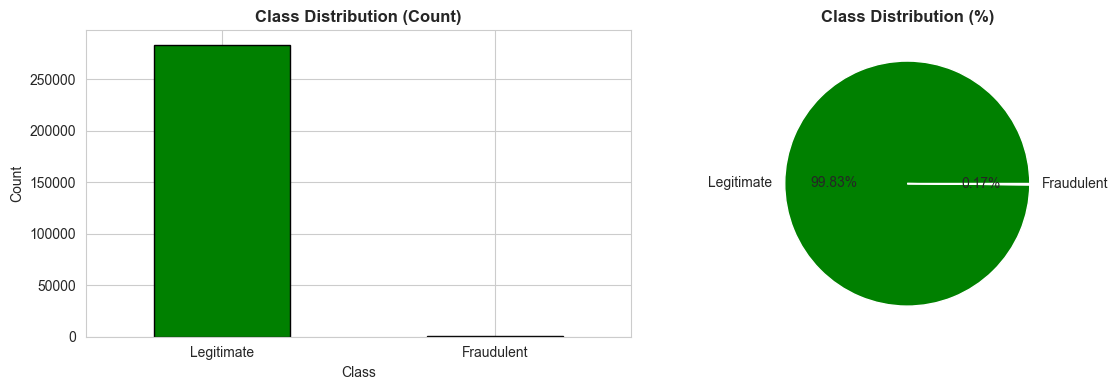

In [7]:
# Class distribution
class_counts = creditcard_clean['Class'].value_counts()
class_pct = creditcard_clean['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"Legitimate (0): {class_counts[0]} ({class_pct[0]:.2f}%)")
print(f"Fraudulent (1): {class_counts[1]} ({class_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: {class_counts[0] / class_counts[1]:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0], edgecolor='black', color=['green', 'red'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

class_pct.plot(kind='pie', ax=axes[1], labels=['Legitimate', 'Fraudulent'], autopct='%1.2f%%', colors=['green', 'red'])
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Exploratory Data Analysis - Univariate Analysis

In [8]:
# Basic statistics
print("Statistical Summary:")
print(creditcard_clean.describe())

Statistical Summary:
                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -

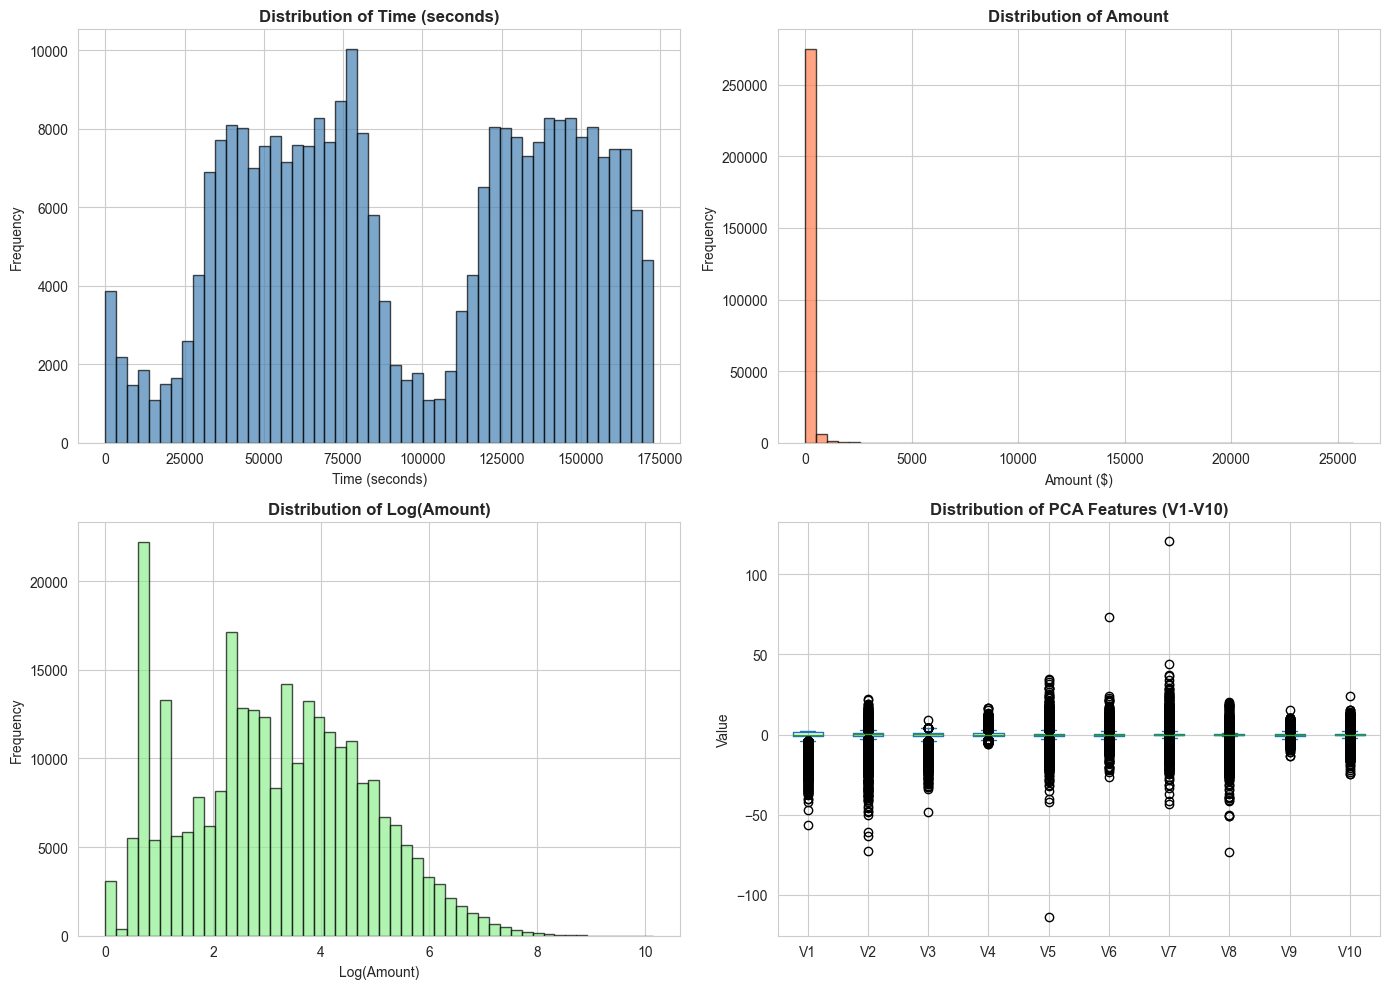

In [9]:
# Distribution of Time and Amount features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time distribution
axes[0, 0].hist(creditcard_clean['Time'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Time (seconds)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Frequency')

# Amount distribution
axes[0, 1].hist(creditcard_clean['Amount'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribution of Amount', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Amount ($)')
axes[0, 1].set_ylabel('Frequency')

# Log-scaled Amount
axes[1, 0].hist(np.log1p(creditcard_clean['Amount']), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_title('Distribution of Log(Amount)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Log(Amount)')
axes[1, 0].set_ylabel('Frequency')

# Box plot of PCA features (V1-V10 for visualization)
pca_features = [col for col in creditcard_clean.columns if col.startswith('V')][:10]
creditcard_clean[pca_features].plot(kind='box', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of PCA Features (V1-V10)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_univariate.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# PCA features statistics
print("\nPCA Features (V1-V28) Statistics:")
pca_all = [col for col in creditcard_clean.columns if col.startswith('V')]
print(f"Number of PCA features: {len(pca_all)}")
print(f"\nFirst 5 PCA features:")
print(creditcard_clean[pca_all[:5]].describe())


PCA Features (V1-V28) Statistics:
Number of PCA features: 28

First 5 PCA features:
                  V1             V2             V3             V4  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean        0.005917      -0.004135       0.001613      -0.002966   
std         1.948026       1.646703       1.508682       1.414184   
min       -56.407510     -72.715728     -48.325589      -5.683171   
25%        -0.915951      -0.600321      -0.889682      -0.850134   
50%         0.020384       0.063949       0.179963      -0.022248   
75%         1.316068       0.800283       1.026960       0.739647   
max         2.454930      22.057729       9.382558      16.875344   

                  V5  
count  283726.000000  
mean        0.001828  
std         1.377008  
min      -113.743307  
25%        -0.689830  
50%        -0.053468  
75%         0.612218  
max        34.801666  


## 5. Bivariate Analysis - Features vs Target

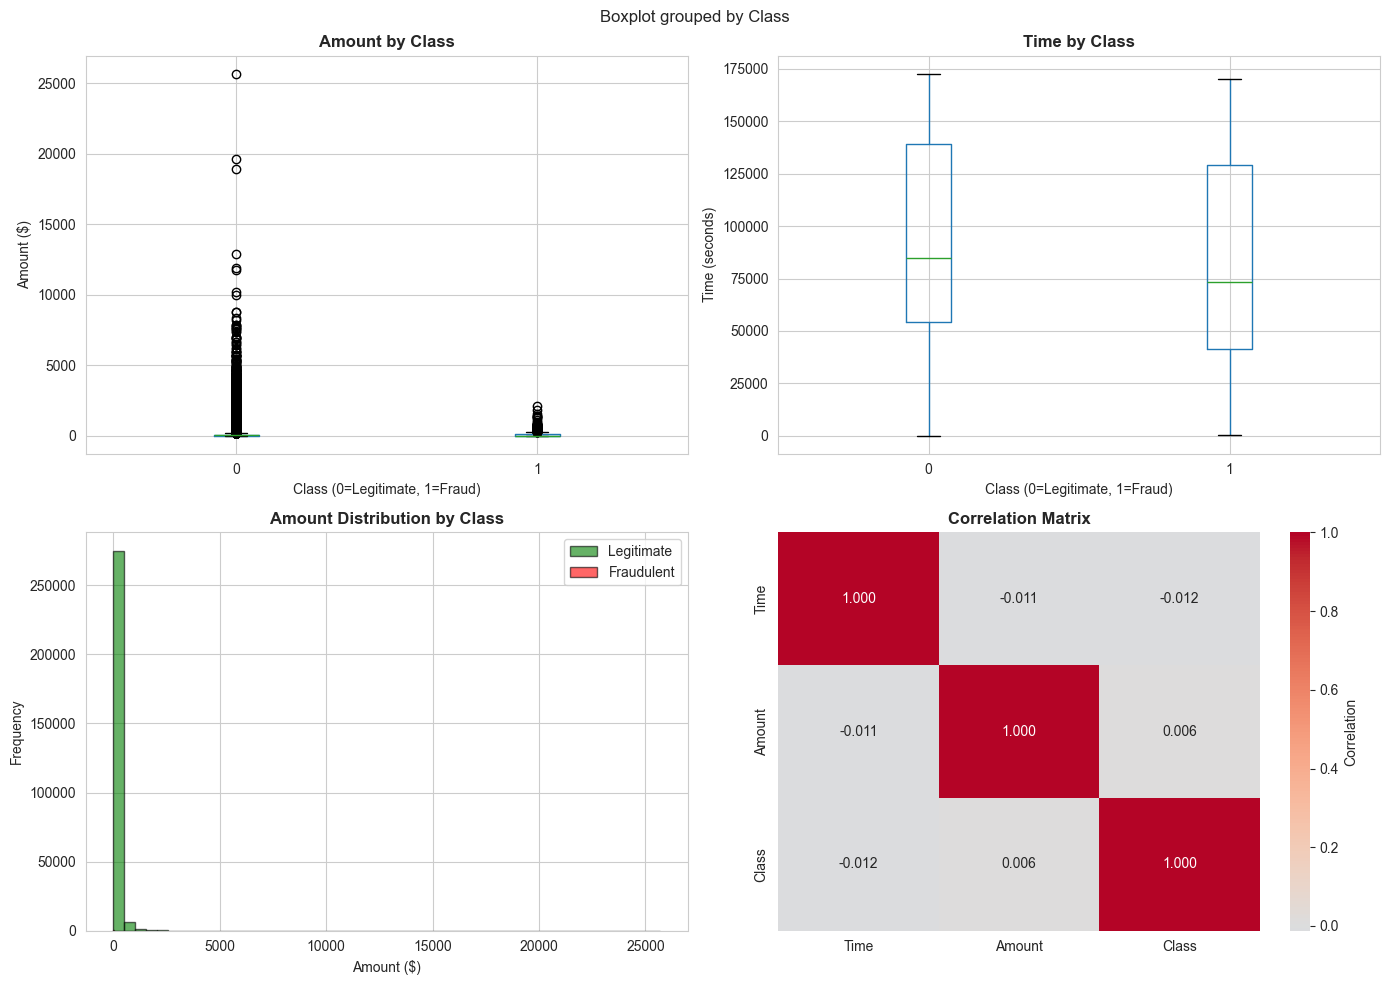

In [11]:
# Amount by class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot - Amount by class
creditcard_clean.boxplot(column='Amount', by='Class', ax=axes[0, 0])
axes[0, 0].set_title('Amount by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 0].set_ylabel('Amount ($)')

# Box plot - Time by class
creditcard_clean.boxplot(column='Time', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Time by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 1].set_ylabel('Time (seconds)')

# Distribution of Amount by class
legitimate_amount = creditcard_clean[creditcard_clean['Class'] == 0]['Amount']
fraud_amount = creditcard_clean[creditcard_clean['Class'] == 1]['Amount']

axes[1, 0].hist(legitimate_amount, bins=50, alpha=0.6, label='Legitimate', edgecolor='black', color='green')
axes[1, 0].hist(fraud_amount, bins=50, alpha=0.6, label='Fraudulent', edgecolor='black', color='red')
axes[1, 0].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Correlation of Amount and Time with Class
corr_data = creditcard_clean[['Time', 'Amount', 'Class']].corr()
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_bivariate.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Amount statistics by class
print("\nAmount Statistics by Class:")
print("\nLegitimate Transactions:")
print(legitimate_amount.describe())

print("\n\nFraudulent Transactions:")
print(fraud_amount.describe())

print("\n\nComparison:")
print(f"Mean Amount - Legitimate: ${legitimate_amount.mean():.2f}")
print(f"Mean Amount - Fraudulent: ${fraud_amount.mean():.2f}")
print(f"Median Amount - Legitimate: ${legitimate_amount.median():.2f}")
print(f"Median Amount - Fraudulent: ${fraud_amount.median():.2f}")


Amount Statistics by Class:

Legitimate Transactions:
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64


Fraudulent Transactions:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


Comparison:
Mean Amount - Legitimate: $88.41
Mean Amount - Fraudulent: $123.87
Median Amount - Legitimate: $22.00
Median Amount - Fraudulent: $9.82


## 6. PCA Feature Analysis

Top 15 PCA Features Most Correlated with Class:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
V1    -0.094486
V9    -0.094021
V5    -0.087812
V2     0.084624
V6    -0.043915
Name: Class, dtype: float64


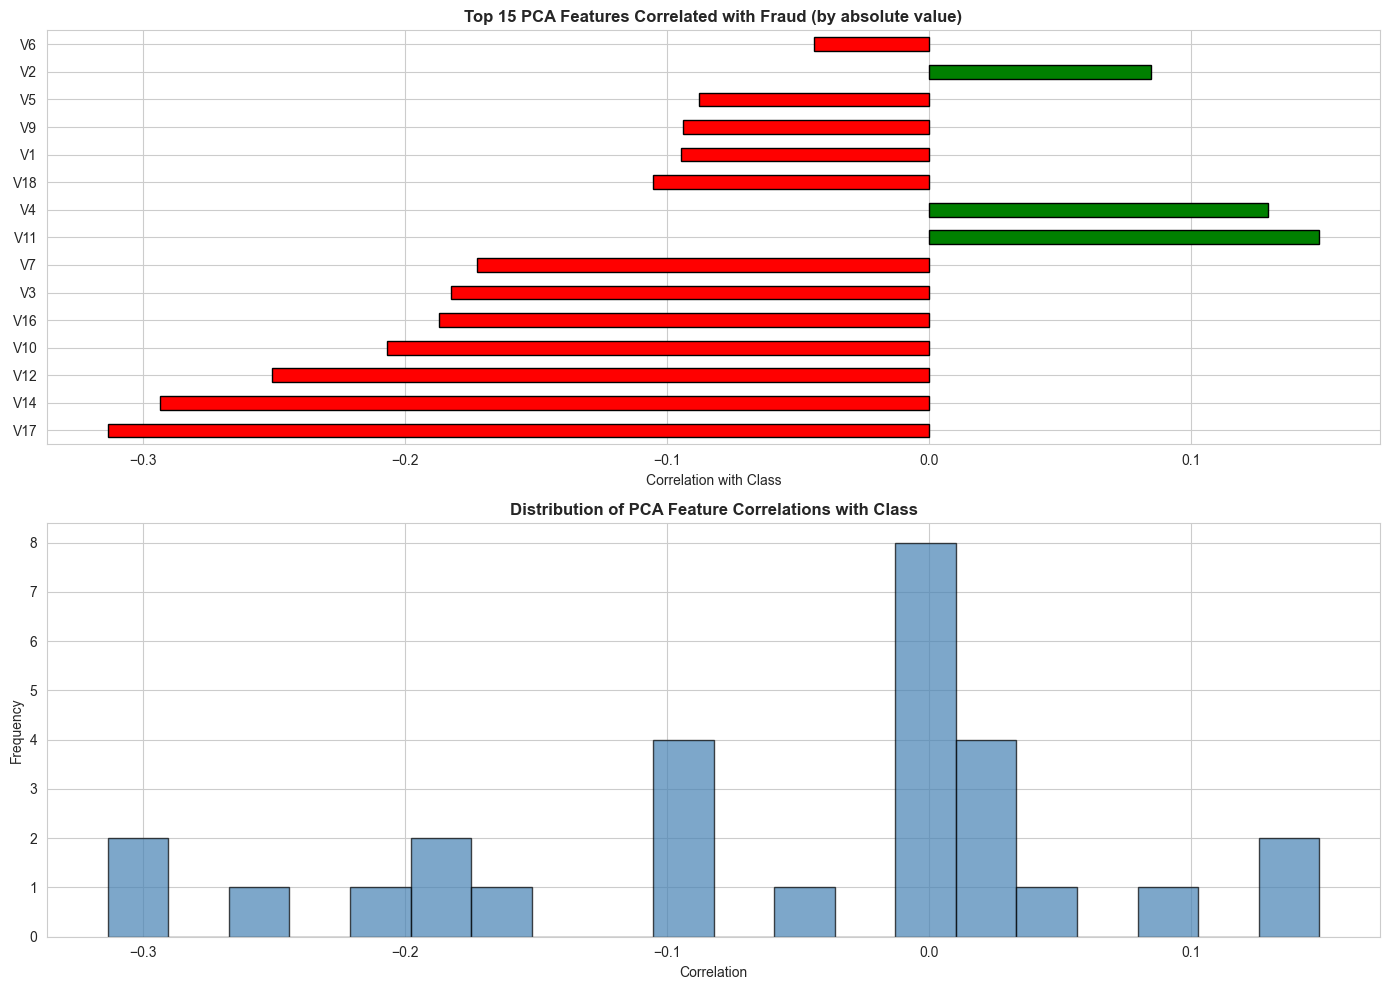

In [13]:
# Correlation of PCA features with Class
pca_features = [col for col in creditcard_clean.columns if col.startswith('V')]

# Calculate correlations
correlations = creditcard_clean[[*pca_features, 'Class']].corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("Top 15 PCA Features Most Correlated with Class:")
print(correlations.head(15))

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 15 positive correlations
top_corr = correlations.head(15)
top_corr.plot(kind='barh', ax=axes[0], color=['green' if x > 0 else 'red' for x in top_corr], edgecolor='black')
axes[0].set_title('Top 15 PCA Features Correlated with Fraud (by absolute value)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation with Class')

# Distribution of correlations
axes[1].hist(correlations, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('Distribution of PCA Feature Correlations with Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/processed/creditcard_pca_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

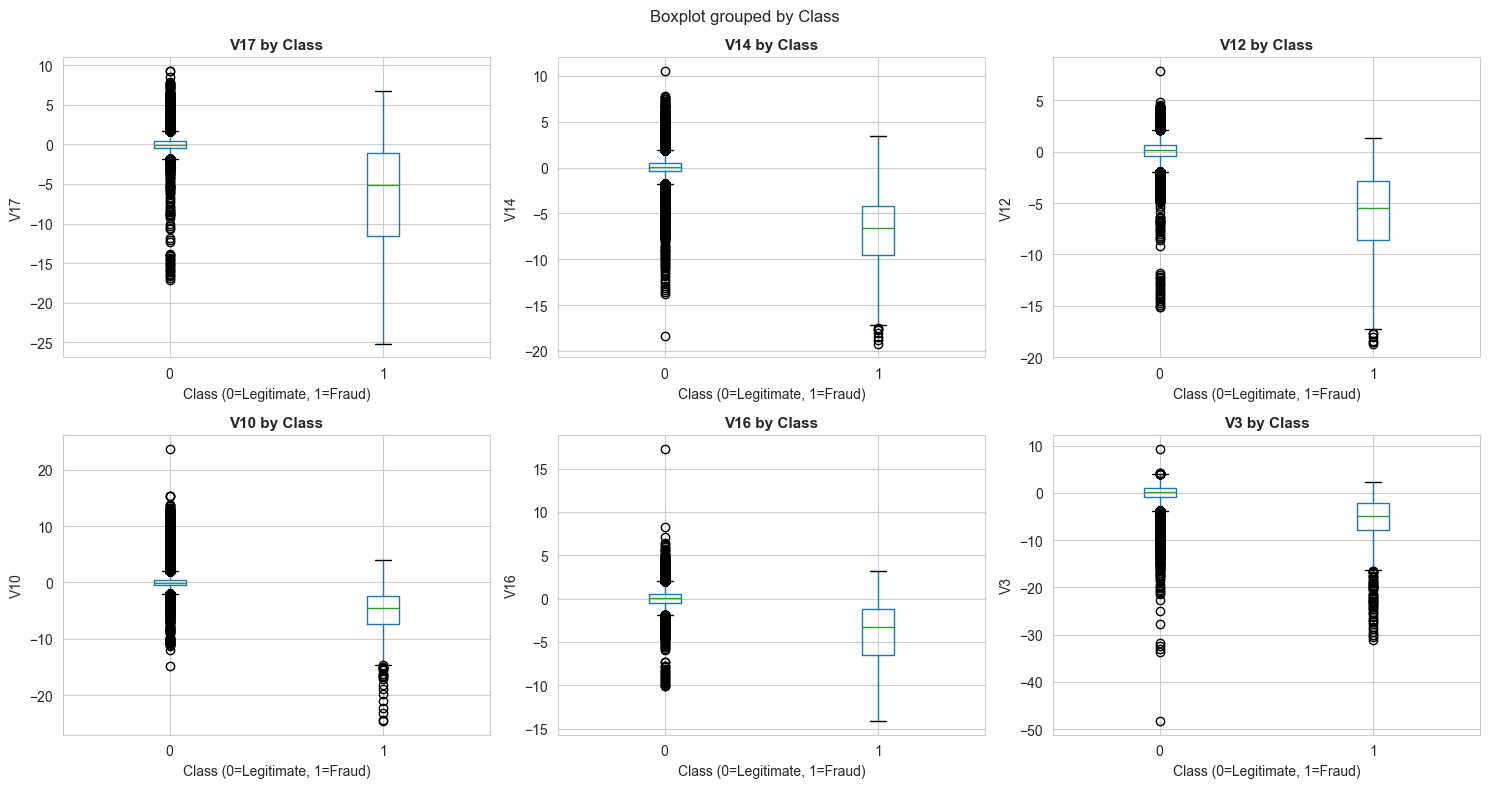

In [14]:
# Box plots of top PCA features by class
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    creditcard_clean.boxplot(column=feature, by='Class', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Class', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Class (0=Legitimate, 1=Fraud)')
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.savefig('../data/processed/creditcard_top_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary and Data Quality Report

In [15]:
# Create comprehensive EDA summary
summary_report = f"""
{'='*70}
FRAUD DETECTION EDA SUMMARY REPORT - creditcard.csv
{'='*70}

1. DATA OVERVIEW
   Total Records: {len(creditcard_clean):,}
   Total Columns: {len(creditcard_clean.columns)}
   Duplicates Removed: {len(creditcard_data) - len(creditcard_clean)}
   Missing Values: {creditcard_clean.isnull().sum().sum()}

2. COLUMN STRUCTURE
   Time: Transaction elapsed time (seconds)
   V1-V28: PCA-transformed anonymized features (28 features)
   Amount: Transaction amount
   Class: Target variable (0=Legitimate, 1=Fraudulent)

3. CLASS IMBALANCE
   Legitimate Transactions: {class_counts[0]:,} ({class_pct[0]:.2f}%)
   Fraudulent Transactions: {class_counts[1]:,} ({class_pct[1]:.2f}%)
   Imbalance Ratio: {class_counts[0] / class_counts[1]:.2f}:1

4. KEY FEATURES STATISTICS
   
   Time (seconds):
   - Min: {creditcard_clean['Time'].min()}
   - Max: {creditcard_clean['Time'].max()}
   - Mean: {creditcard_clean['Time'].mean():.2f}
   - Median: {creditcard_clean['Time'].median():.2f}
   
   Amount ($):
   - Min: ${creditcard_clean['Amount'].min():.2f}
   - Max: ${creditcard_clean['Amount'].max():.2f}
   - Mean: ${creditcard_clean['Amount'].mean():.2f}
   - Median: ${creditcard_clean['Amount'].median():.2f}

5. AMOUNT COMPARISON BY CLASS
   Legitimate - Mean: ${legitimate_amount.mean():.2f}, Median: ${legitimate_amount.median():.2f}
   Fraudulent - Mean: ${fraud_amount.mean():.2f}, Median: ${fraud_amount.median():.2f}

6. TOP 5 PCA FEATURES (by correlation with fraud)
   {correlations.head(5).to_string()}

7. DATA QUALITY
   - No missing values detected
   - All features are numerical
   - Features are already transformed (PCA)
   - Data is clean and ready for preprocessing

{'='*70}
"""

print(summary_report)

# Save report
with open('../data/processed/Creditcard_EDA_Summary_Report.txt', 'w') as f:
    f.write(summary_report)


FRAUD DETECTION EDA SUMMARY REPORT - creditcard.csv

1. DATA OVERVIEW
   Total Records: 283,726
   Total Columns: 31
   Duplicates Removed: 1081
   Missing Values: 0

2. COLUMN STRUCTURE
   Time: Transaction elapsed time (seconds)
   V1-V28: PCA-transformed anonymized features (28 features)
   Amount: Transaction amount
   Class: Target variable (0=Legitimate, 1=Fraudulent)

3. CLASS IMBALANCE
   Legitimate Transactions: 283,253 (99.83%)
   Fraudulent Transactions: 473 (0.17%)
   Imbalance Ratio: 598.84:1

4. KEY FEATURES STATISTICS

   Time (seconds):
   - Min: 0.0
   - Max: 172792.0
   - Mean: 94811.08
   - Median: 84692.50

   Amount ($):
   - Min: $0.00
   - Max: $25691.16
   - Mean: $88.47
   - Median: $22.00

5. AMOUNT COMPARISON BY CLASS
   Legitimate - Mean: $88.41, Median: $22.00
   Fraudulent - Mean: $123.87, Median: $9.82

6. TOP 5 PCA FEATURES (by correlation with fraud)
   V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186

7. DATA QUALITY
   

## 8. Save Processed Data

In [16]:
# Save the processed data
print("Saving processed data...")

creditcard_clean.to_csv('../data/processed/creditcard_cleaned_eda.csv', index=False)
print(f"Saved: creditcard_cleaned_eda.csv ({len(creditcard_clean)} rows)")

print("\nProcessed data saved successfully!")

Saving processed data...
Saved: creditcard_cleaned_eda.csv (283726 rows)

Processed data saved successfully!
